# EXERCISE 1: Data Analysis using mtcars

In [12]:
import pandas as pd

df = pd.read_csv('mtcars.csv')

# 1. Find the car with the best mpg

In [13]:
best_mpg = df.nlargest(1, 'mpg')[['model', 'mpg']]
print(f"Best MPG: {best_mpg.iloc[0]['model']} - {best_mpg.iloc[0]['mpg']} mpg")


Best MPG: Toyota Corolla - 33.9 mpg


# 2. Find the car with the worst mpg

In [14]:
worst_mpg = df.nsmallest(1, 'mpg')[['model', 'mpg']]
print(f"Worst MPG: {worst_mpg.iloc[0]['model']} - {worst_mpg.iloc[0]['mpg']} mpg")


Worst MPG: Cadillac Fleetwood - 10.4 mpg


# 3. Find the car with the best horsepower

In [15]:
best_hp  = df.nlargest(1, 'hp')[['model', 'hp']]
print(f"Best Horsepower: {best_hp.iloc[0]['model']} - {best_hp.iloc[0]['hp']} hp")

Best Horsepower: Maserati Bora - 335 hp


# 4. Find 5 number summary of displacement

In [16]:
# df['disp'].quantile([0, 0.25, 0.5, 0.75, 1])
disp_summary = df['disp'].describe(percentiles=[0.25, 0.5, 0.75])
five_number = {
    'Min': df['disp'].min(),
    'Q1': disp_summary['25%'],
    'Median': disp_summary['50%'],
    'Q3': disp_summary['75%'],
    'Max': df['disp'].max()
}

print("Five-number summary of displacement:", five_number)

Five-number summary of displacement: {'Min': 71.1, 'Q1': 120.825, 'Median': 196.3, 'Q3': 326.0, 'Max': 472.0}


# 5. Find median horse power

In [17]:
median_hp = df['hp'].median()
print("Median horsepower:", median_hp)

Median horsepower: 123.0


# 6. What is average mpg for manual vs. automatic cars


In [18]:
df.groupby('am')['mpg'].mean().rename({0: 'Automatic', 1: 'Manual'})


am
Automatic    17.147368
Manual       24.392308
Name: mpg, dtype: float64

# 7. Draw a histogram of miles per gallon 


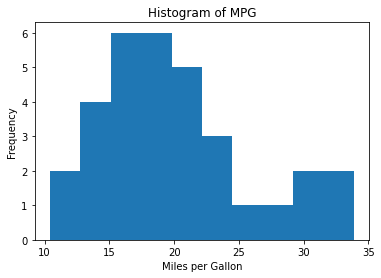

In [19]:
# Histogram of MPG
import matplotlib.pyplot as plt

df['mpg'].plot(kind='hist', bins=10, title='Histogram of MPG')
plt.xlabel('Miles per Gallon')
plt.show()

# 8. Boxplot of mpg for each cylinder type 


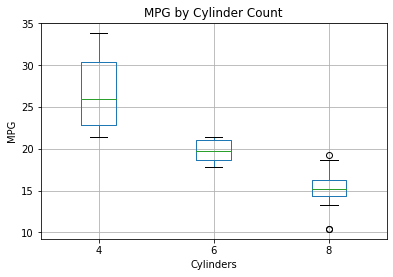

In [20]:
df.boxplot(column='mpg', by='cyl')
plt.title('MPG by Cylinder Count')
plt.suptitle('')  
plt.xlabel('Cylinders')
plt.ylabel('MPG')
plt.show()

# 9. Create a crosstab displaying count of automatic vs. manual cars 


In [21]:
# Transmission count
print("Transmission Count:\n", 
      pd.crosstab(df['am'].replace({0: 'Automatic', 1: 'Manual'}), columns='count'))

Transmission Count:
 col_0      count
am              
Automatic     19
Manual        13


# 10. Create a crosstab displaying count of “am vs cyl” 

In [22]:
# AM vs CYL crosstab
print("\nAM vs CYL Crosstab:\n", 
      pd.crosstab(df['am'].replace({0: 'Automatic', 1: 'Manual'}), df['cyl']))


AM vs CYL Crosstab:
 cyl        4  6   8
am                 
Automatic  3  4  12
Manual     8  3   2


# 11. What is the correlation between the weight of the car and mpg

In [23]:
correlation = df['wt'].corr(df['mpg'])
print("Correlation between weight and mpg:", round(correlation, 2))


Correlation between weight and mpg: -0.87


# EXERCISE 2: Descriptive Analytics and Visualization 

In [24]:
import pandas as pd

df = pd.read_csv('bollywood.csv')
df

,SlNo,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,18-Apr-14,2 States,LW,Romance,36,104.00,8576361,26622,2527
1,2,4-Jan-13,Table No. 21,N,Thriller,10,12.00,1087320,1129,137
2,3,18-Jul-14,Amit Sahni Ki List,N,Comedy,10,4.00,572336,586,54
3,4,4-Jan-13,Rajdhani Express,N,Drama,7,0.35,42626,86,19
4,5,4-Jul-14,Bobby Jasoos,N,Comedy,18,10.80,3113427,4512,1224
...,...,...,...,...,...,...,...,...,...,...
144,145,27-Feb-15,Dum Laga Ke Haisha,N,Comedy,15,30.00,3250917,8185,615
145,146,13-Mar-15,NH10,N,Thriller,13,32.10,5592977,15464,1513
146,147,20-Mar-15,Dilliwali Zaalim Girlfriend,N,Comedy,32,12.00,2316047,4289,807
147,148,20-Mar-15,Hunterrr,N,Comedy,5,11.89,4674795,3706,762


# 1. How many records are present in the dataset?  

In [25]:
len(df)


149

# 2. How many movies got released in each genre? Sort number of releases in each genre in descending order.  


In [26]:
genre_counts = df['Genre'].str.strip().value_counts()
print(genre_counts)

Comedy      36
Drama       35
Thriller    29
Romance     25
Action      24
Name: Genre, dtype: int64


# 3. Which genre had highest number of releases?  


In [27]:
top_genre = genre_counts.idxmax()
top_count = genre_counts.max()

print("Top Genre:", top_genre)
print("Count:", top_count)


Top Genre: Comedy
Count: 36


# 4. How many movies in each genre got released in different release times like long  weekend, festive season, etc.

In [28]:
df['ReleaseTime'] = df['ReleaseTime'].str.strip()
genre_release_crosstab = pd.crosstab(df['Genre'], df['ReleaseTime'])
genre_release_crosstab

ReleaseTime,FS,HS,LW,N
Genre,,,,
Drama,4,6,1,24
Action,3,3,3,12
Action,0,0,0,3
Comedy,3,5,5,23
Romance,3,3,4,15
Thriller,4,1,1,20
Thriller,0,0,1,2


# 5. Which month of the year, maximum number movie releases are seen? 

In [29]:
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Month'] = df['Release Date'].dt.month
month_counts = df['Month'].value_counts()
top_month = month_counts.idxmax()
top_month

1

# 6. Which month of the year typically sees most releases of high budgeted movies, that is,  movies with budget of 25 crore or more?  


In [30]:
high_budget = df[df['Budget'] >= 25]
high_budget_month = high_budget['Month'].value_counts().idxmax()
high_budget_month 

2

# 7. Which are the top 10 movies with maximum return on investment (ROI)? Calculate return on investment (ROI) as (BoxOfficeCollection – Budget) / Budget.  
 

In [31]:
df['ROI'] = (df['BoxOfficeCollection'] - df['Budget']) / df['Budget']
top_10_roi = df.sort_values(by='ROI', ascending=False)[['MovieName', 'ROI']].head(10)
top_10_roi

,MovieName,ROI
64,Aashiqui 2,8.166667
89,PK,7.647059
132,Grand Masti,7.514286
135,The Lunchbox,7.500000
87,Fukrey,6.240000
58,Mary Kom,5.933333
128,Shahid,5.666667
37,Humpty Sharma Ki Dulhania,5.500000
101,Bhaag Milkha Bhaag,4.466667
115,Chennai Express,4.266667


# 8. Do the movies have higher ROI if they get released on festive seasons or long weekend? Calculate the average ROI for different release times.  


In [32]:
avg_roi_by_time = df.groupby('ReleaseTime')['ROI'].mean()
avg_roi_by_time 

ReleaseTime
FS    0.973853
HS    0.850867
LW    1.127205
N     0.657722
Name: ROI, dtype: float64

# 9. Is there a correlation between box office collection and YouTube likes? Is the correlation positive or negative?  


In [33]:
correlation = df['BoxOfficeCollection'].corr(df['YoutubeLikes'])
correlation_type = 'positive' if correlation > 0 else 'negative'
correlation_type 

'positive'

# 10. Which genre of movies typically sees more YouTube likes? Draw boxplots for each genre of movies to compare. 

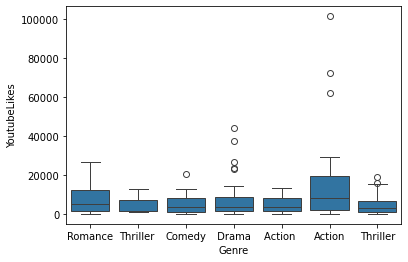

In [35]:
import seaborn as sns

sns.boxplot(x='Genre', y='YoutubeLikes', data=df)
plt.show()


# 11. Which of the variables among Budget, BoxOfficeCollection, YoutubeView, YoutubeLikes, YoutubeDislikes are highly correlated? 

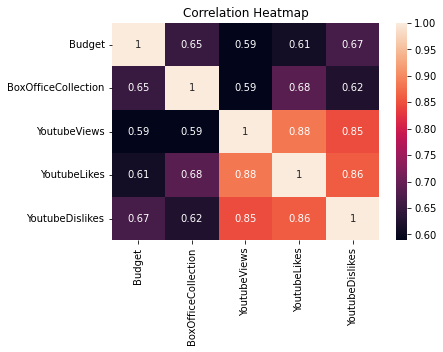

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df[['Budget', 'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']].corr()
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Heatmap')
plt.show()


# 12. During 2013−2015 period, highlight the genre of movies and their box office collection? Visualize with best fit graph.  


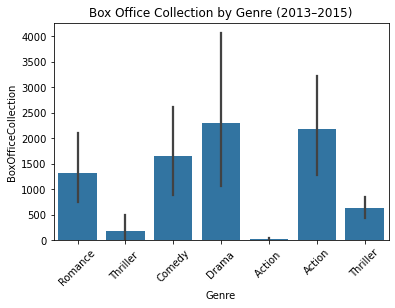

In [37]:
df_period = df[df['Release Date'].dt.year.isin([2013, 2014, 2015])]
sns.barplot(x='Genre', y='BoxOfficeCollection', data=df_period, estimator=sum)
plt.xticks(rotation=45)
plt.title('Box Office Collection by Genre (2013–2015)')
plt.show()


# 13. Visualize  the Budget and Box office collection based on Genre.  


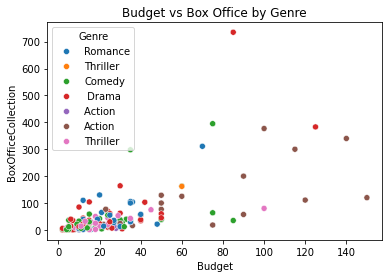

In [38]:
sns.scatterplot(x='Budget', y='BoxOfficeCollection', hue='Genre', data=df)
plt.title('Budget vs Box Office by Genre')
plt.show()


# 14. Find the distribution of movie budget for every Genre.  


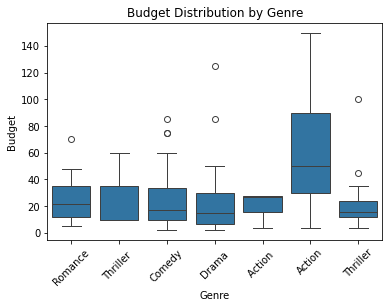

In [39]:
sns.boxplot(x='Genre', y='Budget', data=df)
plt.xticks(rotation=45)
plt.title('Budget Distribution by Genre')
plt.show()


# 15. During 2013−2015, find the number of movies released in every year. Also, visualize with best fit graph.

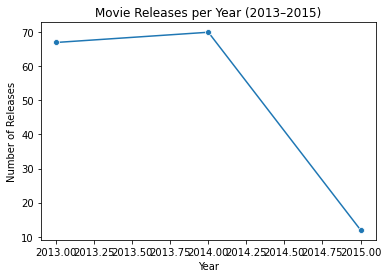

In [40]:
df['Year'] = df['Release Date'].dt.year
year_counts = df[df['Year'].between(2013, 2015)]['Year'].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title('Movie Releases per Year (2013–2015)')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.show()
